# CodeAlpha - Task-3. Car Price Prediction using Machine Learning

## 1.Import Required Libraries

In [2]:
# Data handling and visualization libraries :

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries :

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## 2.Load Dataset

In [3]:
# Load dataset :

df = pd.read_csv('car_data.csv')
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## 3.Dataset Overview

In [4]:
# Check number of rows and columns:
print('Shape:', df.shape)

# Display column names in list :
print('\nColumns:\n', df.columns.tolist())

# Get dataset information :
print('\nInfo:')
print(df.info())

# Statistical summary of numerical columns :
print('\nDescribe:\n', df.describe())

# Check missing values and give sum of all null values by column :
print('\nMissing Values:\n', df.isnull().sum())

Shape: (301, 9)

Columns:
 ['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']

Info:
<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Selling_type   301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB
None

Describe:
               Year  Selling_Price  Present_Price     Driven_kms       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296     

## 4.Data Preprocessing

In [5]:
# Remove duplicates :
df = df.drop_duplicates()

# Handle missing values :
df = df.ffill()

# Feature Engineering: Create Car Age :
df['Car_Age'] = 2026 - df['Year']
df.drop('Year', axis = 1, inplace = True)

# Encode categorical columns :

encoder = LabelEncoder()
for col in ['Car_Name','Fuel_Type','Selling_type','Transmission']:
    df[col] = encoder.fit_transform(df[col])

df.head()

,Car_Name,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,90,3.35,5.59,27000,2,0,1,0,12
1,93,4.75,9.54,43000,1,0,1,0,13
2,68,7.25,9.85,6900,2,0,1,0,9
3,96,2.85,4.15,5200,2,0,1,0,15
4,92,4.60,6.87,42450,1,0,1,0,12


## 5.Exploratory Data Analysis (EDA)

## 1.Price Distribution

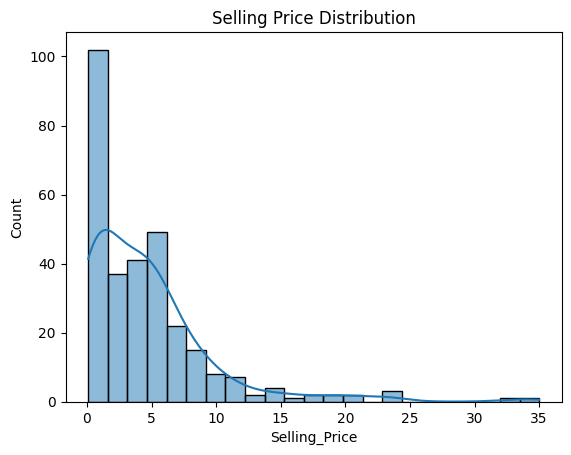

In [6]:
# Selling Price Distribution :

sns.histplot(df['Selling_Price'],kde = True)
plt.title('Selling Price Distribution')

plt.show()

In [ ]:
# Found in Analysis :
# Car prices are not evenly distributed. Most vehicles fall within
# a moderate price range, while fewer vehicles belong to higher price categories.

## 2.Correlation

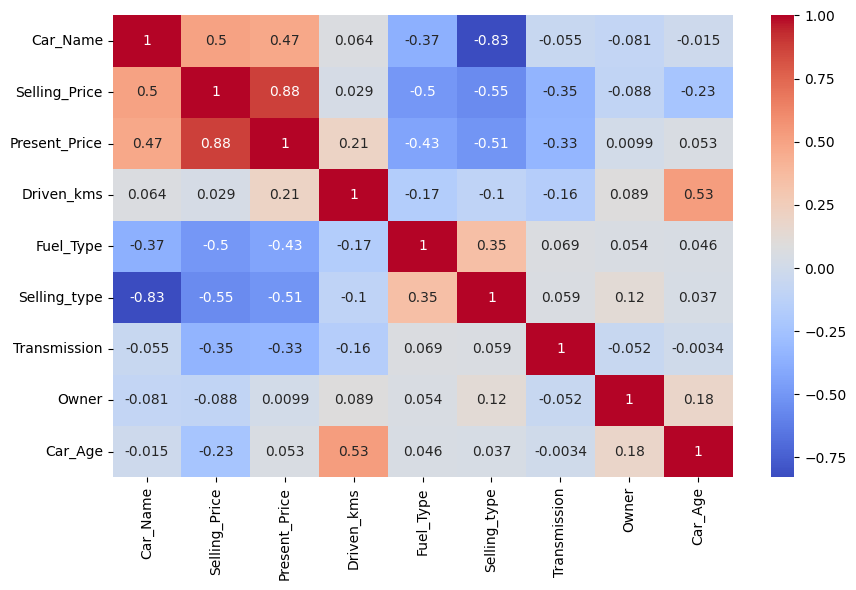

In [8]:
# Correlation Heatmap :

plt.figure(figsize = (10,6))
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm')

plt.show()

In [ ]:
# Found in Analysis :
# Some features show stronger relationships with price than others.
# Highly correlated features may contribute more to prediction accuracy.

## 3.Comparison

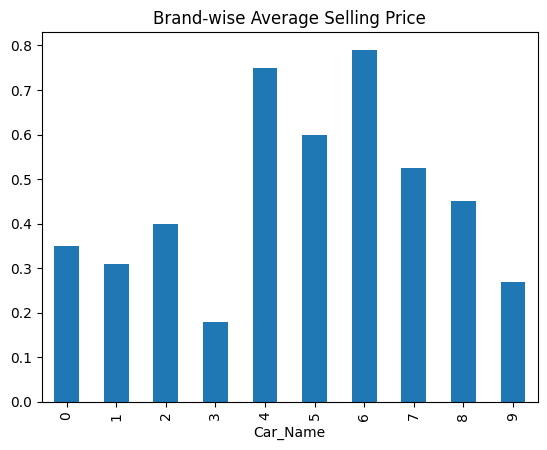

In [9]:
# Brand-wise comparison :

df.groupby('Car_Name')['Selling_Price'].mean().head(10).plot(kind = 'bar')
plt.title('Brand-wise Average Selling Price')

plt.show()

In [ ]:
# Found in Analysis :
# Car_Name has a noticeable impact on price.
# Premium brands generally show higher average prices.

## 4.Relationship

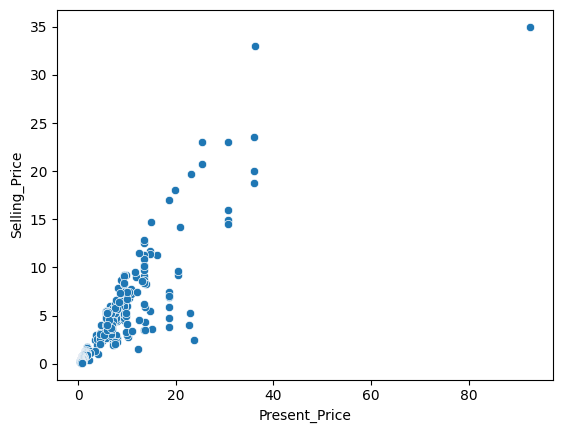

In [10]:
# Relationship between present price and selling price :

sns.scatterplot(data = df,x = 'Present_Price',y = 'Selling_Price')

plt.show()

In [ ]:
# Found in Analysis :
# Selling_Price shows an inverse relationship with Present_Price,
# where higher Selling Price vehicles often have prices.

# 6.Model Building using Machine Learning

In [11]:
# Define features and target:
X = df.drop('Selling_Price',axis = 1)
y = df['Selling_Price']

# Split dataset :
X_train, X_test, y_train, y_test = train_test_split( 
    X , y, test_size = 0.2, random_state = 42
)

# Models :
models = {
    'Linear Regression':LinearRegression(),
    'Decision Tree':DecisionTreeRegressor(random_state = 42),
    'Random Forest':RandomForestRegressor(random_state = 42) 
     }

results = []
trained = {}

for name,model in models.items():
    model.fit(X_train,y_train)
    
    pred = model.predict(X_test)
    
    trained[name] = model
    
    results.append([
        name,
        r2_score(y_test,pred),
        mean_absolute_error(y_test,pred),
        mean_squared_error(y_test,pred),
        np.sqrt(mean_squared_error(y_test,pred))
        ])
result_df = pd.DataFrame(
    results,
    columns = ['Model','R2','MAE','MSE','RMSE']
)

result_df

,Model,R2,MAE,MSE,RMSE
0,Linear Regression,0.734971,1.571961,6.830668,2.613555
1,Decision Tree,0.611788,1.311333,10.005487,3.163145
2,Random Forest,0.611897,1.288437,10.002686,3.162702


In [ ]:
# Conclusion:

# Regression techniques were applied to build a predictive model.
# The model captured important feature interactions and generated
# reliable price estimation based on input variables.

## 7.Price Prediction

In [12]:
# Use Random Forest for prediction:

sample = X.iloc[[0]]
pred = trained['Random Forest'].predict(sample)
print('Predicted Car Price:',round(pred[0],2),'Lakhs')

Predicted Car Price: 3.67 Lakhs


In [ ]:
# Conclusion:

# Price prediction results indicate that the model can estimate
# vehicle prices with reasonable accuracy, supporting data-driven
# decision making in the automotive domain.

In [23]:
# Save cleaned dataset to a specific location :

save_path = r"D:\Internship\CodeAlpha\TASK_3\Outputs\cleaned_Car_Data.csv"

df.to_csv(save_path, index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


## 8.Key Insights
1. Present price strongly affects selling price.
2. Car age reduces price.
3. Fuel type and transmission influence value.
4. Random Forest usually performs better.
5. Feature engineering improves prediction.

## 9.Conclusion
This project predicts car prices using regression models and compares performance using evaluation metrics.